<a href="https://colab.research.google.com/github/ayoubm11/Fashion-MNIST-Classification/blob/main/Copie_de_Mouradi_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Étape 1 : Importer les Bibliothèques Nécessaires

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt


# Étape 2 : Charger le Dataset Fashion MNIST et Visualiser les Données

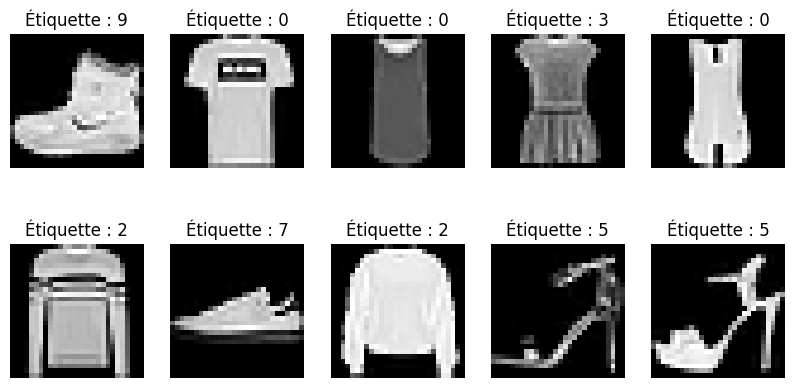

In [ ]:
# Charger les données
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Affichage de quelques images
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Étiquette : {y_train[i]}")
    plt.axis("off")
plt.show()


# Étape 3 : Prétraiter les Données

In [ ]:
# Normalisation des images
X_train = X_train / 255.0
X_test = X_test / 255.0

# Redimensionnement (ajout du canal pour CNN)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Encodage One-Hot des étiquettes — vérification avant encodage
if len(y_train.shape) == 1:
    y_train = to_categorical(y_train, 10)
    y_test = to_categorical(y_test, 10)

# Vérification des dimensions
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (60000, 28, 28, 1)
y_train shape: (60000, 10)


# Étape 4 : Créer le modèle CNN avec Keras

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Étape 5 : Compiler et Entraîner le Modèle

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement
model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 53s 60ms/step - accuracy: 0.6977 - loss: 0.8474 - val_accuracy: 0.8582 - val_loss: 0.3818
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 75s 52ms/step - accuracy: 0.8474 - loss: 0.4249 - val_accuracy: 0.8797 - val_loss: 0.3253
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.8705 - loss: 0.3589 - val_accuracy: 0.8905 - val_loss: 0.3041
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 54ms/step - accuracy: 0.8834 - loss: 0.3258 - val_accuracy: 0.8937 - val_loss: 0.2838
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 52ms/step - accuracy: 0.8913 - loss: 0.2967 - val_accuracy: 0.9042 - val_loss: 0.2617


# Étape 6 : Évaluer le Modèle

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Précision sur le jeu de test : {test_acc*100:.2f}%")


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9020 - loss: 0.2824
Précision sur le jeu de test : 90.09%


# Étape 7 : Faire des Prédictions

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


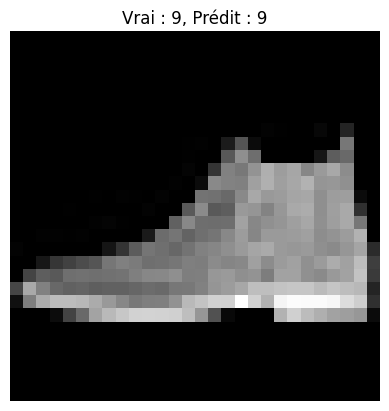

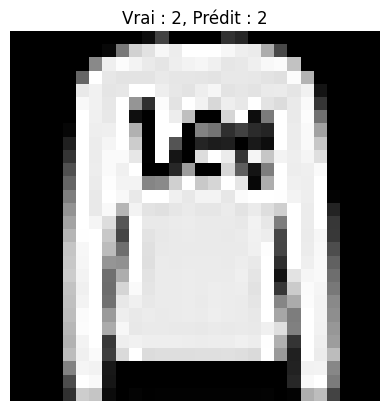

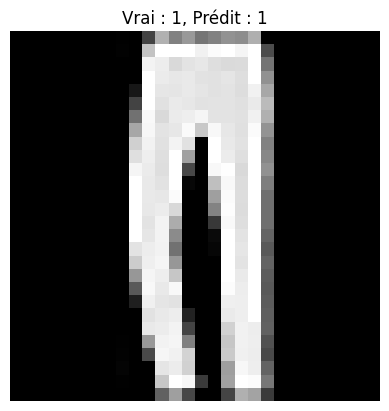

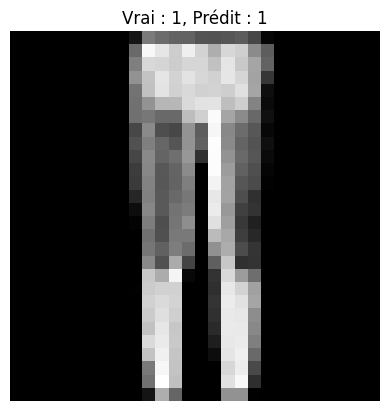

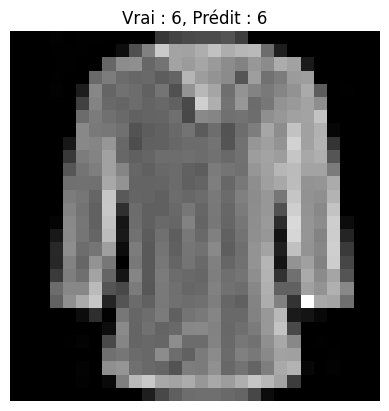

In [ ]:
# Prédictions sur les données de test
predictions = model.predict(X_test)

# Affichage des prédictions pour les 5 premières images
for i in range(5):
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"Vrai : {np.argmax(y_test[i])}, Prédit : {np.argmax(predictions[i])}")
    plt.axis("off")
    plt.show()
